In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("../data/yellow_tripdata_2026.csv")
df

C:\Users\Linh\AppData\Local\Temp\ipykernel_4280\3963665272.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/yellow_tripdata_2026.csv")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.20,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
3,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,11.40,4.25,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
4,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,37.30,1.00,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10444712,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,NaN,13,263,0,50.14,0.00,0.5,0.00,0.0,1.0,60.37,NaN,NaN,0.75
10444713,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,NaN,24,42,0,12.32,0.00,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.00
10444714,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,NaN,62,237,0,47.95,0.00,0.5,0.00,0.0,1.0,52.70,NaN,NaN,0.75
10444715,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,NaN,61,141,0,49.93,0.00,0.5,0.00,0.0,1.0,53.93,NaN,NaN,0.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10444717 entries, 0 to 10444716
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  cbd_congestion_fee     float64
dtypes: float64(13), int64(4), object(3)
memory usage: 1.6+ GB


In [7]:
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

# Hour-of-day 

In [8]:
df_time = df.copy()

# Tạo feature pickup_hour
df_time["pickup_hour"] = (
    df_time["tpep_pickup_datetime"]
    .dt.hour
)

# Tạo feature pickup_date
df_time["pickup_date"] = (
    df_time["tpep_pickup_datetime"]
    .dt.date
)

# Tạo feature day_of_week
df_time["day_of_week"] = (
    df_time["tpep_pickup_datetime"]
    .dt.day_name()
)

In [9]:
# Số giờ theo chuyến đi
hourly_trips = (
    df_time
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trips")
)

hourly_trips

,pickup_hour,trips
0,0,323179
1,1,217382
2,2,143853
3,3,108551
4,4,88921
5,5,98139
6,6,188168
7,7,332820
8,8,436917
9,9,448972


In [10]:
# Peak Hours
hourly_trips.sort_values(
    "trips",
    ascending=False
)


,pickup_hour,trips
18,18,693124
17,17,657691
21,21,644676
19,19,636615
20,20,636450
15,15,610366
16,16,589946
22,22,578191
14,14,577142
13,13,539893


In [11]:
# Off-Peak
hourly_trips.sort_values(
    "trips"
)

,pickup_hour,trips
4,4,88921
5,5,98139
3,3,108551
2,2,143853
6,6,188168
1,1,217382
0,0,323179
7,7,332820
8,8,436917
23,23,442057


In [12]:
# Morning Commute
df_time["period"] = "Other"

df_time.loc[
    df_time.pickup_hour.between(7,9),
    "period"
] = "Morning commute"
df_time["period"].value_counts()

period
Other              9226008
Morning commute    1218709
Name: count, dtype: int64

In [13]:
# Evening Commute
df_time.loc[
    df_time.pickup_hour.between(16,19),
    "period"
] = "Evening commute"
df_time["period"].value_counts()

period
Other              6648632
Evening commute    2577376
Morning commute    1218709
Name: count, dtype: int64

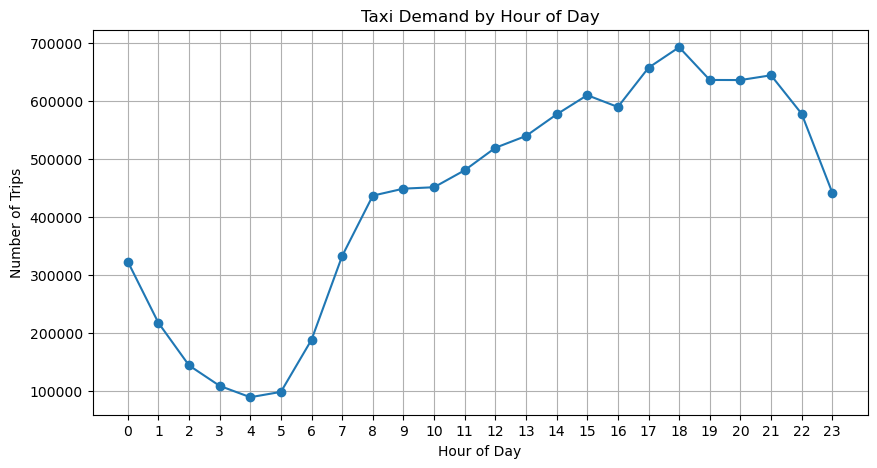

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    hourly_trips["pickup_hour"],
    hourly_trips["trips"],
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Hour of Day")

plt.xticks(range(24))
plt.grid(True)

plt.show()

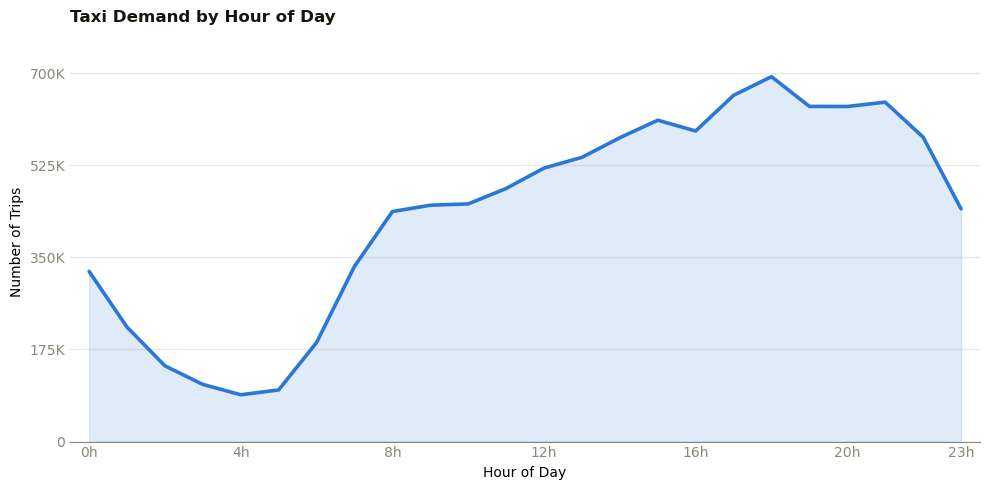

In [15]:
# Biểu đồ nhu cầu theo giờ — dạng area, nền trắng, màu xanh
import matplotlib.pyplot as plt

hours = hourly_trips["pickup_hour"].to_numpy()
trips = hourly_trips["trips"].to_numpy()

BLUE, INK, MUTED = "#2a78d6", "#16150E", "#8A867A"

fig, ax = plt.subplots(figsize=(10, 5))

# Vùng nền + đường
ax.fill_between(hours, trips, color=BLUE, alpha=0.14, zorder=1)
ax.plot(hours, trips, color=BLUE, linewidth=2.6, solid_capstyle="round", zorder=2)

# Trục & lưới
ax.set_title("Taxi Demand by Hour of Day", loc="left",
             color=INK, fontweight="bold", fontsize=12, pad=14)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")
ax.set_yticks([0, 175000, 350000, 525000, 700000])
ax.set_yticklabels(["0", "175K", "350K", "525K", "700K"])
ax.set_xticks([0, 4, 8, 12, 16, 20, 23])
ax.set_xticklabels(["0h", "4h", "8h", "12h", "16h", "20h", "23h"])
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, 760000)

ax.grid(axis="y", color=INK, alpha=0.09, linewidth=1)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(MUTED)
ax.tick_params(colors=MUTED, length=0)

plt.tight_layout()
plt.show()

#### Nhận xét:
1. Nhu cầu thay đổi rõ rệt theo thời gian trong ngày: Biểu đồ cho thấy số lượng chuyến đi không phân bố đồng đều trong 24 giờ. Sau nửa đêm, nhu cầu giảm mạnh và đạt mức thấp nhất vào rạng sáng, sau đó tăng nhanh từ buổi sáng và duy trì ở mức cao đến buổi tối.
2. Off-Peak Hours:
- Nhu cầu giảm liên tục từ 0h đến 4h.
- 4h sáng là thời điểm có số chuyến đi thấp nhất (khoảng 88.921 chuyến). Sau 4h, lượng chuyến bắt đầu tăng trở lại (5h đạt 98.139 chuyến).
- Khoảng 2h–5h sáng là thời gian off-peak, phản ánh nhu cầu di chuyển rất thấp trong khoảng thời gian rạng sáng
3. Peak Hours:
- Sau 8h, nhu cầu tiếp tục tăng.
- Đỉnh cao nhất xuất hiện vào khoảng 18h với 693124 chuyến.
- Khung giờ 17h–18h là thời điểm có nhu cầu sử dụng taxi cao nhất trong ngày.
4. Morning Commute:
- Từ 6h đến 8h, số chuyến tăng rất nhanh.
- Chỉ trong khoảng 5h → 8h, số chuyến tăng từ 98139 lên 436917.
- Nhu cầu tăng mạnh vào đầu buổi sáng, đặc biệt từ 6h đến 8h, cho thấy đây nhiều khả năng là giai đoạn người dân bắt đầu di chuyển đến nơi làm việc hoặc trường học.
5. Evening Commute:
- Từ 17h đến 21h, lượng chuyến luôn duy trì ở mức rất cao.
- Sau 21h, nhu cầu bắt đầu giảm nhanh (21h: 644.676 chuyến → 22h: 578.191 chuyến, giảm khoảng 10%).
- Buổi chiều tối có nhu cầu cao hơn buổi sáng và kéo dài trong nhiều giờ.

# Day-of-week 

In [16]:
# Ngày trong tuần
df["pickup_day"] = (
    df["tpep_pickup_datetime"]
    .dt.day_name()
)

In [17]:
df["day_type"] = np.where(
    df["tpep_pickup_datetime"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

In [18]:
day_demand = (
    df.groupby("pickup_day")
      .size()
      .reset_index(name="trips")
)
print(day_demand)

  pickup_day    trips
0     Friday  1626531
1     Monday  1178538
2   Saturday  1719637
3     Sunday  1349159
4   Thursday  1668632
5    Tuesday  1463680
6  Wednesday  1438540


In [19]:
week_type = (
    df.groupby("day_type")
      .size()
      .reset_index(name="trips")
)
print(week_type)

  day_type    trips
0  Weekday  7375921
1  Weekend  3068796


In [20]:
df["pickup_hour"] = (
    df["tpep_pickup_datetime"]
    .dt.hour
)

In [21]:
result = df.groupby(
    ["day_type","pickup_hour"]
).size()

In [22]:
result 

day_type  pickup_hour
Weekday   0              139628
          1               74269
          2               44632
          3               32759
          4               39282
          5               72136
          6              155466
          7              291428
          8              374747
          9              357366
          10             333177
          11             343162
          12             365048
          13             374079
          14             416262
          15             446276
          16             415598
          17             473275
          18             495491
          19             453775
          20             479695
          21             490514
          22             415155
          23             292701
Weekend   0              183551
          1              143113
          2               99221
          3               75792
          4               49639
          5               26003
          6       

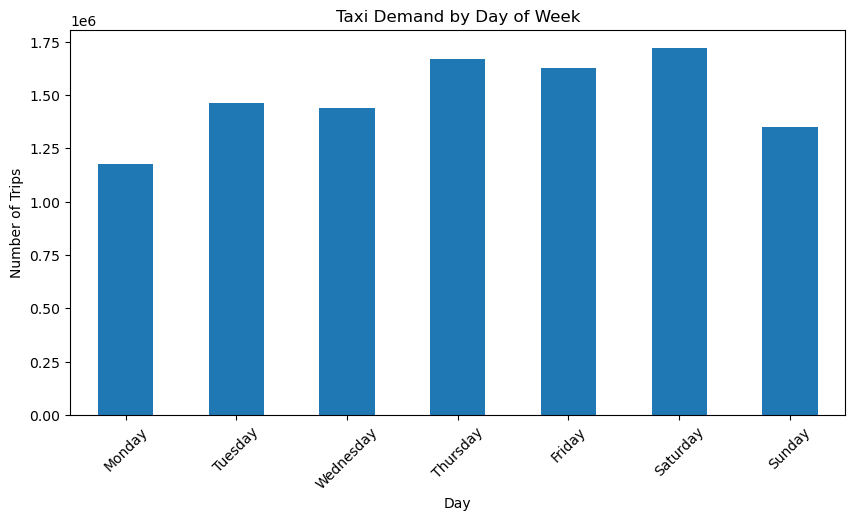

In [23]:
import matplotlib.pyplot as plt

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_demand = (
    df["pickup_day"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(10,5))
day_demand.plot(kind="bar")

plt.title("Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.show()

#### Nhận xét:
1. Xu hướng trong tuần: Nhu cầu sử dụng taxi không phân bố đồng đều giữa các ngày. Nhìn chung nhu cầu tăng từ đầu tuần lên cuối tuần và đạt đỉnh vào thứ Bảy, sau đó giảm mạnh vào Chủ Nhật. Tuy nhiên xu hướng này không tăng đều: thứ Sáu vẫn thấp hơn thứ Năm.
2. Trong giai đoạn Q1/2026, thứ Tư chỉ xuất hiện 12 lần trong khi các thứ còn lại xuất hiện 13 lần, nên tổng của thứ Tư bị hụt do cấu trúc lịch chứ không phải do nhu cầu thấp. Vì vậy nên so sánh bằng trung bình số chuyến/ngày:
- Thứ Bảy: 132.280 chuyến/ngày (cao nhất)
- Thứ Năm: 128.356 chuyến/ngày
- Thứ Sáu: 125.118 chuyến/ngày
- Thứ Tư: 119.878 chuyến/ngày
- Thứ Ba: 112.591 chuyến/ngày
- Chủ Nhật: 103.781 chuyến/ngày
- Thứ Hai: 90.657 chuyến/ngày (thấp nhất)
3. Ngày có nhu cầu cao nhất:
- Thứ Bảy ghi nhận số lượng chuyến đi cao nhất trong tuần (tổng 1.719.637 chuyến)
- Sau đó là thứ Năm (1.668.632 chuyến)
- Tiếp theo là thứ Sáu (1.626.531 chuyến)
4. Thứ Hai có số chuyến đi thấp nhất trong tuần (tổng 1.178.538 chuyến, trung bình 90.657 chuyến/ngày). Tuy nhiên mức thấp này bị phóng đại bởi hai ngày chịu ảnh hưởng thời tiết đều rơi vào thứ Hai (26/01: 62.673 chuyến và 23/02: 22.733 chuyến). Nếu loại hai ngày này, trung bình thứ Hai là 99.376 chuyến/ngày — vẫn thấp nhất tuần, nhưng khoảng cách với Chủ Nhật (108.813 chuyến/ngày sau khi loại ngày bão 25/01) thu hẹp đáng kể.


In [24]:
# Số chuyến theo từng ngày
daily_trips = (
    df.groupby(df["tpep_pickup_datetime"].dt.date)
      .size()
      .reset_index(name="trips")
)

daily_trips["day_type"] = pd.to_datetime(
    daily_trips["tpep_pickup_datetime"]
).dt.dayofweek.map(
    lambda x: "Weekday" if x < 5 else "Weekend"
)

In [25]:
# Trung bình
avg_daily = (
    daily_trips.groupby("day_type")["trips"]
    .mean()
    .reset_index()
)

avg_daily

,day_type,trips
0,Weekday,115248.765625
1,Weekend,118030.615385


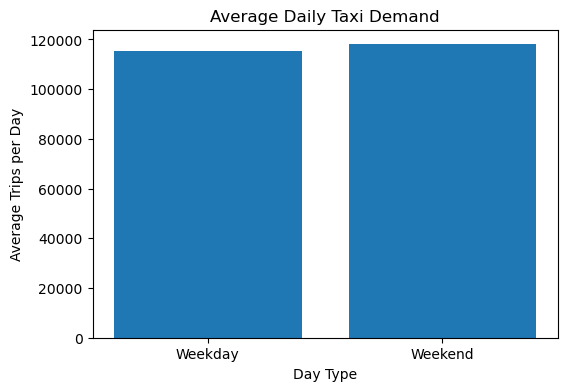

In [26]:
plt.figure(figsize=(6,4))

plt.bar(
    avg_daily["day_type"],
    avg_daily["trips"]
)

plt.title("Average Daily Taxi Demand")
plt.xlabel("Day Type")
plt.ylabel("Average Trips per Day")

plt.show()

#### Nhận xét:
- Trung bình số chuyến trong cuối tuần là 118.031 chuyến/ngày.
- Trung bình số chuyến trong ngày thường là 115.249 chuyến/ngày.
- Chênh lệch khoảng 2.782 chuyến/ngày, tương đương khoảng 2,4%.
- Nhu cầu sử dụng taxi vào cuối tuần cao hơn nhẹ so với các ngày trong tuần.

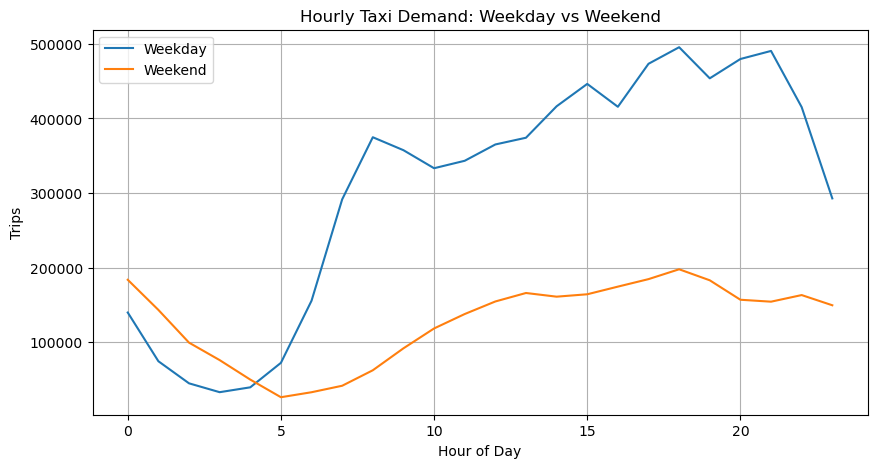

In [27]:
hour_pattern = (
    df.groupby(
        ["day_type","pickup_hour"]
    )
    .size()
    .reset_index(name="trips")
)
plt.figure(figsize=(10,5))

for t in ["Weekday","Weekend"]:
    temp = hour_pattern[
        hour_pattern["day_type"] == t
    ]

    plt.plot(
        temp["pickup_hour"],
        temp["trips"],
        label=t
    )

plt.title(
    "Hourly Taxi Demand: Weekday vs Weekend"
)

plt.xlabel("Hour of Day")
plt.ylabel("Trips")

plt.legend()
plt.grid()
plt.show()

In [28]:
df["pickup_date"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
).dt.date

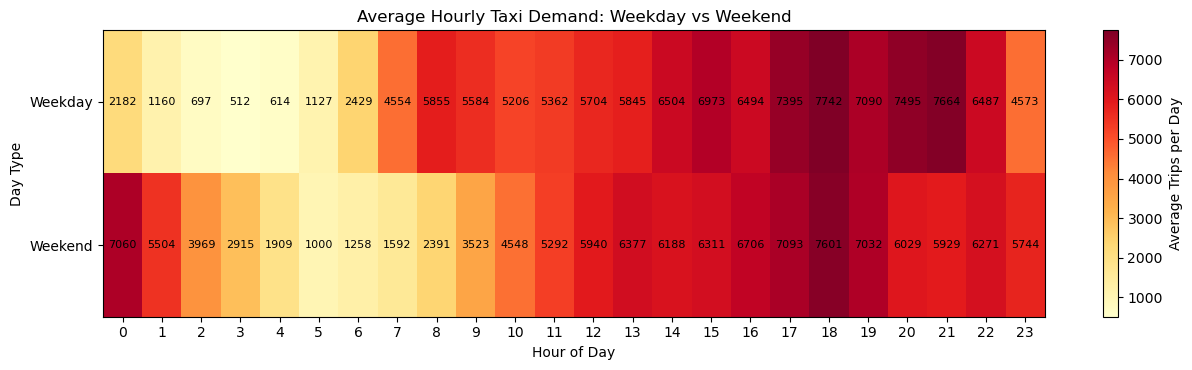

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Average trips per hour

# Đếm số chuyến theo từng ngày, loại ngày và giờ
daily_hourly = (
    df.groupby(["pickup_date", "day_type", "pickup_hour"])
      .size()
      .reset_index(name="trips")
)

# Tính trung bình số chuyến của mỗi giờ
hour_pattern = (
    daily_hourly
    .groupby(["day_type", "pickup_hour"])["trips"]
    .mean()
    .reset_index()
)

# Pivot thành ma trận
heatmap_data = (
    hour_pattern
    .pivot(
        index="day_type",
        columns="pickup_hour",
        values="trips"
    )
    .reindex(["Weekday", "Weekend"])
)

# Plot Heatmap
fig, ax = plt.subplots(figsize=(13, 3.8))

im = ax.imshow(
    heatmap_data,
    cmap="YlOrRd",
    aspect="auto"
)

# Trục X
ax.set_xticks(np.arange(24))
ax.set_xticklabels(range(24))

# Trục Y
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Hiển thị giá trị trên từng ô
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.0f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Thanh màu
cbar = plt.colorbar(im)
cbar.set_label("Average Trips per Day")

# Tiêu đề
ax.set_title("Average Hourly Taxi Demand: Weekday vs Weekend")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day Type")

plt.tight_layout()
plt.show()

#### Nhận xét:

1. Xu hướng chung (Trend)
- Cả Weekday và Weekend đều đạt đỉnh vào chiều tối (khoảng 18h) với mức gần như bằng nhau: Weekday 7.742 chuyến/ngày, Weekend 7.601 chuyến/ngày (chênh 1,9%).
- Khác biệt giữa hai nhóm không nằm ở mức đỉnh mà ở hình dạng phân bố trong ngày: Weekday có đáy rạng sáng rất sâu và cao điểm chiều tối rõ rệt, còn Weekend dịch chuyển toàn bộ chu kỳ về sau vài giờ.
- Biên độ dao động của Weekday lớn hơn: từ 512 lên 7.742 chuyến/ngày (khoảng 15 lần), trong khi Weekend từ 1.000 lên 7.601 chuyến/ngày (khoảng 7,6 lần).

2. Peak Hour
- Weekday: khung 17h–21h đều duy trì trên 7.000 chuyến/ngày, đỉnh tại 18h (7.742), tiếp theo là 21h (7.664) và 20h (7.495) — cao điểm kéo dài liên tục khoảng 5 tiếng.
- Weekend: đỉnh tại 18h (7.601), sau đó là 17h (7.093) và 19h (7.032). Ngoài ra 0h cũng đạt 7.060 chuyến/ngày, ngang với khung cao điểm chiều tối.
=> Mức đỉnh của hai nhóm gần như tương đương. Chênh lệch lớn ở số tổng (495.491 so với 197.633 chuyến tại 18h) chủ yếu do Weekday có 64 ngày còn Weekend chỉ có 26 ngày, không phản ánh nhu cầu mỗi ngày.

3. Off-Peak
- Weekday: đáy rơi vào khung 02h–05h, thấp nhất là 03h với 512 chuyến/ngày.
- Weekend: đáy rơi vào khung 05h–07h, thấp nhất là 05h với 1.000 chuyến/ngày — muộn hơn Weekday khoảng 2 tiếng.
=> Cả hai nhóm đều thấp nhất vào rạng sáng, nhưng thời điểm chạm đáy lệch nhau rõ rệt.

4. So sánh hai nhóm
- Đêm khuya — khác biệt lớn nhất: Weekend vượt xa Weekday ở khung 0h–4h. 0h: 7.060 so với 2.182 chuyến/ngày (+224%); 1h: 5.504 so với 1.160 (+375%); 2h: 3.969 so với 697 (+469%); 3h: 2.915 so với 512 (+469%). Đây là nhu cầu di chuyển về sau các hoạt động giải trí buổi tối cuối tuần.
- Cao điểm sáng chỉ tồn tại ở Weekday: Weekday tăng rất nhanh từ 06h đến 08h (2.429 → 4.554 → 5.855 chuyến/ngày), phản ánh giờ đi làm và đi học. Weekend hoàn toàn không có cao điểm này: 07h chỉ đạt 1.592 chuyến/ngày (thấp hơn Weekday 65%) và 08h đạt 2.391 chuyến/ngày (thấp hơn 59%).
- Buổi trưa và chiều: hai nhóm gần như trùng nhau, khung 12h–19h chênh lệch dưới 700 chuyến/ngày, cho thấy nhu cầu ban ngày ít phụ thuộc vào loại ngày.
- Cuối buổi tối: Weekday cao hơn ở 20h–21h (7.495 và 7.664 so với 6.029 và 5.929 chuyến/ngày), nhưng đến 23h thì Weekend vượt lên (5.744 so với 4.573 chuyến/ngày) — khởi đầu cho chênh lệch đêm khuya đã nêu ở trên.


# Seasonal Pattern

In [30]:
df["pickup_date"] = (
    df["tpep_pickup_datetime"]
    .dt.date
)

daily_trips = (
    df
    .groupby("pickup_date")
    .size()
    .reset_index(name="trips")
)

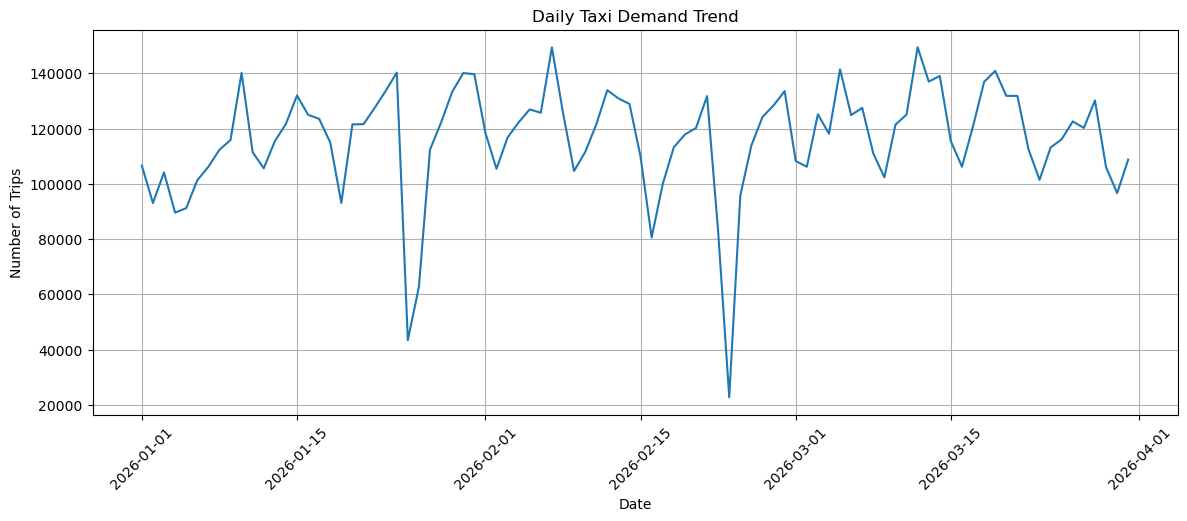

In [31]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_trips["pickup_date"],
    daily_trips["trips"]
)

plt.title("Daily Taxi Demand Trend")
plt.xlabel("Date")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.grid()

plt.show()

#### Nhận xét: 
1. Xu hướng chung:
Nhu cầu taxi trong giai đoạn từ tháng 1 đến tháng 3 không có xu hướng tăng hoặc giảm rõ rệt theo thời gian.
Đường xu hướng có nhiều biến động ngắn hạn giữa các ngày liên tiếp, phản ánh nhu cầu taxi chịu ảnh hưởng bởi các yếu tố thay đổi hàng ngày như lịch làm việc, thời tiết hoặc sự kiện.
2. Biến động theo ngày:
Nhu cầu taxi có sự dao động đáng kể giữa các ngày:
Một số ngày đạt mức cao khoảng 145,000 – 150,000 chuyến/ngày.
Một số ngày giảm mạnh xuống dưới 50,000 chuyến/ngày.
Các điểm giảm bất thường xuất hiện rõ rệt vào:
- Cuối tháng 1 
- Cuối tháng 2 
3. Giai đoạn nhu cầu cao:
Các giai đoạn có nhu cầu cao nhất đạt khoảng 140,000 – 150,000 chuyến/ngày.
Một số đỉnh nổi bật xuất hiện:
- Đầu tháng 2.
- Giữa tháng 3.
4. Giai đoạn nhu cầu thấp
Ngoài hai điểm giảm bất thường, phần lớn các ngày có nhu cầu duy trì trên 100,000 chuyến/ngày.
Các mức giảm sâu không xuất hiện thường xuyên, cho thấy hệ thống taxi vẫn duy trì nhu cầu ổn định trong toàn bộ giai đoạn.

### Ngày bất thường

In [32]:
# Xác định các ngày bất thường
from scipy.stats import zscore

# Tính z-score cho số chuyến mỗi ngày
daily_trips["z_score"] = zscore(
    daily_trips["trips"]
)

# Lấy các ngày bất thường
anomalies = daily_trips[
    abs(daily_trips["z_score"]) > 3
]

anomalies

,pickup_date,trips,z_score
24,2026-01-25,43407,-3.631778
53,2026-02-23,22733,-4.665338


#### Nhận xét:
1. Với ngày 2026-01-25 tại New York City, điểm bất thường đến từ sự kiện thời tiết cực đoan. Sự kiện đáng chú ý nhất là: Major Winter Storm (Bão mùa đông lớn) tại New York City. Vào ngày 25/01/2026, New York City chịu ảnh hưởng của một trận bão mùa đông lớn. Cơ quan vệ sinh New York phát cảnh báo tuyết, dự báo lượng tuyết lớn và yêu cầu người dân hạn chế ra ngoài nếu không cần thiết.
2. Phân tích điểm bất thường ngày 23/02/2026
+ Số chuyến taxi ghi nhận: 22.733 chuyến
+ Nguyên nhân chính: do trận bão tuyết nghiêm trọng xảy ra tại New York vào ngày 23/02/2026. Do ảnh hưởng của thời tiết cực đoan: Chính quyền thành phố New York đã ban hành tình trạng khẩn cấp và hạn chế việc đi lại không cần thiết.
Nhiều tuyến đường, cầu và hệ thống giao thông bị hạn chế hoạt động để đảm bảo an toàn.
Tuyết rơi dày kèm theo gió mạnh khiến việc di chuyển trong thành phố trở nên khó khăn.
Người dân hạn chế ra ngoài, làm giảm nhu cầu sử dụng các phương tiện di chuyển như taxi.
Do đó, sự sụt giảm mạnh số lượng chuyến taxi trong ngày 23/02/2026 không phải là biến động ngẫu nhiên của dữ liệu mà có liên quan trực tiếp đến một yếu tố bên ngoài là điều kiện thời tiết khắc nghiệt.


### Holiday Effect

In [33]:
#
holidays = [
    "2026-01-01",
    "2026-01-19",
    "2026-02-16",
]

daily_trips["holiday"] = (
    daily_trips["pickup_date"]
    .astype(str)
    .isin(holidays)
)

In [34]:
holiday_dates = [
    "2026-01-01",
    "2026-01-19",
    "2026-02-16",
]

holiday_trips = daily_trips[
    daily_trips["pickup_date"].astype(str).isin(holiday_dates)
]

holiday_trips

,pickup_date,trips,z_score,holiday
0,2026-01-01,106592,-0.472956,True
18,2026-01-19,93074,-1.148765,True
46,2026-02-16,80567,-1.774030,True


In [35]:
df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-01").date()
]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_day,day_type,pickup_hour,pickup_date
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,0.0,1.0,15.86,2.5,0.0,0.00,Thursday,Weekday,0,2026-01-01
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,0.0,1.0,55.56,2.5,0.0,0.75,Thursday,Weekday,0,2026-01-01
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,...,0.0,1.0,24.94,2.5,0.0,0.75,Thursday,Weekday,0,2026-01-01
3,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,...,0.0,1.0,17.15,2.5,0.0,0.75,Thursday,Weekday,0,2026-01-01
4,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,...,0.0,1.0,51.66,2.5,0.0,0.75,Thursday,Weekday,0,2026-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550049,2,2026-01-01 23:14:51,2026-01-01 23:31:32,NaN,2.50,NaN,NaN,79,90,0,...,0.0,1.0,23.80,NaN,NaN,0.75,Thursday,Weekday,23,2026-01-01
2550050,2,2026-01-01 23:49:53,2026-01-01 23:55:47,NaN,1.41,NaN,NaN,144,137,0,...,0.0,1.0,14.42,NaN,NaN,0.75,Thursday,Weekday,23,2026-01-01
2550051,2,2026-01-01 23:12:18,2026-01-01 23:32:39,NaN,4.90,NaN,NaN,239,224,0,...,0.0,1.0,29.84,NaN,NaN,0.75,Thursday,Weekday,23,2026-01-01
2550052,2,2026-01-01 23:18:43,2026-01-01 23:27:46,NaN,1.25,NaN,NaN,75,41,0,...,0.0,1.0,15.59,NaN,NaN,0.00,Thursday,Weekday,23,2026-01-01


In [36]:
df_newyear = df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-01").date()
]

df_newyear["hour"] = (
    df_newyear["tpep_pickup_datetime"]
    .dt.hour
)

df_newyear["hour"].value_counts().sort_index()

C:\Users\Linh\AppData\Local\Temp\ipykernel_4280\4076752593.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_newyear["hour"] = (


hour
0     8997
1     9860
2     7489
3     6281
4     3932
5     2121
6     2024
7     1867
8     1648
9     2171
10    3058
11    4133
12    5060
13    5194
14    5408
15    5960
16    4728
17    4540
18    4259
19    4045
20    4111
21    3879
22    3244
23    2583
Name: count, dtype: int64

In [37]:
df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-19").date()
]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_day,day_type,pickup_hour,pickup_date
1482882,2,2026-01-19 00:09:48,2026-01-19 00:20:26,1.0,1.90,1.0,N,230,236,1,...,0.00,1.0,21.42,2.5,0.00,0.75,Monday,Weekday,0,2026-01-19
1482883,2,2026-01-19 00:00:19,2026-01-19 00:18:24,1.0,9.87,1.0,N,138,229,1,...,7.46,1.0,72.01,2.5,1.75,0.75,Monday,Weekday,0,2026-01-19
1482884,2,2026-01-19 00:26:29,2026-01-19 00:37:14,3.0,2.26,1.0,N,161,249,1,...,0.00,1.0,20.41,2.5,0.00,0.75,Monday,Weekday,0,2026-01-19
1482885,2,2026-01-19 00:34:35,2026-01-19 00:51:14,1.0,3.11,1.0,N,232,68,1,...,0.00,1.0,27.77,2.5,0.00,0.75,Monday,Weekday,0,2026-01-19
1482886,2,2026-01-19 00:57:25,2026-01-19 01:29:04,2.0,7.06,1.0,N,246,37,1,...,0.00,1.0,47.25,2.5,0.00,0.75,Monday,Weekday,0,2026-01-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3058588,2,2026-01-19 23:10:52,2026-01-19 23:27:52,NaN,5.47,NaN,NaN,164,87,0,...,0.00,1.0,42.68,NaN,NaN,0.75,Monday,Weekday,23,2026-01-19
3058589,2,2026-01-19 23:37:40,2026-01-20 00:03:14,NaN,9.67,NaN,NaN,87,238,0,...,0.00,1.0,38.93,NaN,NaN,0.75,Monday,Weekday,23,2026-01-19
3058590,2,2026-01-19 23:23:47,2026-01-19 23:46:52,NaN,4.45,NaN,NaN,74,48,0,...,0.00,1.0,23.96,NaN,NaN,0.75,Monday,Weekday,23,2026-01-19
3058591,2,2026-01-19 23:31:20,2026-01-19 23:41:22,NaN,1.69,NaN,NaN,224,90,0,...,0.00,1.0,17.83,NaN,NaN,0.75,Monday,Weekday,23,2026-01-19


In [38]:
df_Martin = df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-01-19").date()
]

df_Martin["hour"] = (
    df_Martin["tpep_pickup_datetime"]
    .dt.hour
)

df_Martin["hour"].value_counts().sort_index()

C:\Users\Linh\AppData\Local\Temp\ipykernel_4280\906725578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Martin["hour"] = (


hour
0     3397
1     1784
2     1065
3      802
4      793
5      877
6     1397
7     1869
8     2865
9     3825
10    4546
11    5293
12    5866
13    5839
14    6855
15    6846
16    5814
17    5473
18    5733
19    5213
20    5101
21    4747
22    3712
23    3362
Name: count, dtype: int64

In [39]:
# Presidents' Day (Washington's Birthday) — 16/02/2026 (Thứ Hai)
df_presidents = df[
    df["tpep_pickup_datetime"].dt.date == pd.to_datetime("2026-02-16").date()
]

df_presidents["hour"] = (
    df_presidents["tpep_pickup_datetime"]
    .dt.hour
)

df_presidents["hour"].value_counts().sort_index()

C:\Users\Linh\AppData\Local\Temp\ipykernel_4280\2919806687.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_presidents["hour"] = (


hour
0     3079
1     1764
2     1054
3      829
4      818
5      770
6     1291
7     1599
8     2479
9     3069
10    3732
11    4361
12    4682
13    5125
14    5418
15    5559
16    4983
17    5393
18    5338
19    4582
20    4408
21    4436
22    3388
23    2410
Name: count, dtype: int64

### Phân bố theo giờ — 3 ngày lễ

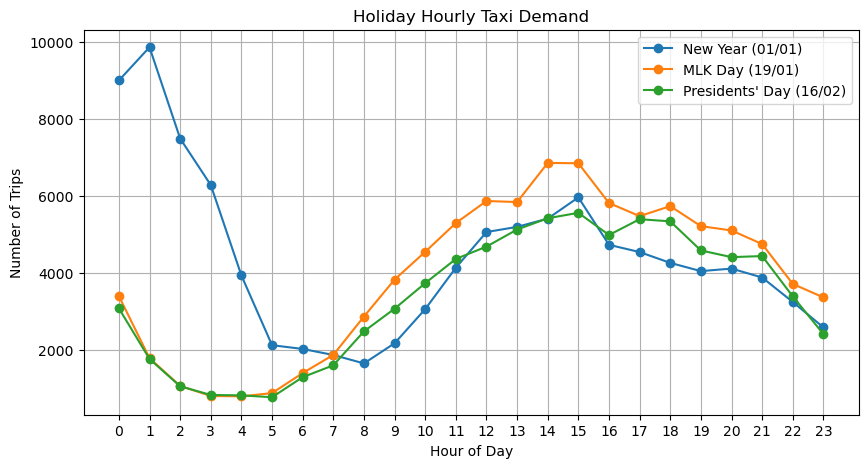

In [40]:
# Biểu đồ theo giờ của 3 ngày lễ
import matplotlib.pyplot as plt

holiday_map = {
    "New Year (01/01)":        "2026-01-01",
    "MLK Day (19/01)":         "2026-01-19",
    "Presidents' Day (16/02)": "2026-02-16",
}

plt.figure(figsize=(10, 5))

for label, date in holiday_map.items():
    day = df[df["tpep_pickup_datetime"].dt.date == pd.to_datetime(date).date()]
    hourly = (
        day["tpep_pickup_datetime"].dt.hour
        .value_counts()
        .reindex(range(24), fill_value=0)
        .sort_index()
    )
    plt.plot(hourly.index, hourly.values, marker="o", label=label)

plt.title("Holiday Hourly Taxi Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

#### Nhận xét:
1. Ngày 01/01/2026 – New Year's Day (Thứ Năm)
- Loại ngày: Holiday
- Số chuyến taxi: 106.592 chuyến
- Nhận xét phân bố theo giờ – 01/01/2026: 
    + Nhu cầu rất cao vào rạng sáng (00:00–02:00)
    + 00:00: 8.997 chuyến
    + 01:00: 9.860 chuyến (cao nhất trong ngày)
    + 02:00: 7.489 chuyến

=> Giải thích: Người dân di chuyển sau các hoạt động đón giao thừa (New Year's Eve).
→ Taxi đóng vai trò quan trọng trong việc di chuyển an toàn sau khi tham gia các hoạt động ban đêm.
- Giảm mạnh vào buổi sáng (05:00–09:00)
    + 05:00: 2.121 chuyến
    + 06:00: 2.024 chuyến
    + 07:00: 1.867 chuyến
    + 08:00: 1.648 chuyến (thấp nhất ngày)

=> Giải thích: Ngày lễ nên: Người dân nghỉ làm, trường học đóng cửa. Không có nhu cầu đi làm vào giờ cao điểm.
2. Ngày 19/01/2026 – Martin Luther King Jr. Day (Thứ Hai)
- Loại ngày: Ngày lễ (Holiday)
- Tổng số chuyến taxi: 93.074 chuyến
- Nhu cầu rất thấp vào rạng sáng (01:00–06:00). Số chuyến theo giờ:
    + 01:00: 1.784 chuyến
    + 02:00: 1.065 chuyến
    + 03:00: 802 chuyến
    + 04:00: 793 chuyến (thấp nhất trong ngày)
    + 05:00: 877 chuyến
- Giảm mạnh nhu cầu đi lại buổi sáng. Trong ngày thường, New York thường có giờ cao điểm buổi sáng do người dân đi làm: Tuy nhiên, ngày 19/01:
    + 07:00: 1.869
    + 08:00: 2.865
    + 09:00: 3.825

=> Giải thích: Ngày 19/01 là Martin Luther King Jr. Day, một ngày nghỉ liên bang: Nhiều công ty đóng cửa, trường học nghỉ, người lao động không cần di chuyển đến nơi làm việc.
- Nhu cầu tăng cao vào buổi chiều (12:00–16:00):
    + Các khung giờ có nhiều chuyến nhất. Đỉnh cao nhất: 
    + 14:00: 6.855 chuyến
    + 15:00: 6.846 chuyến

=> Giải thích: Trong ngày nghỉ, hành vi di chuyển thay đổi: Người dân đi mua sắm, đi ăn uống, đi thăm gia đình, bạn bè, tham gia các hoạt động cá nhân. Do đó, nhu cầu taxi chuyển từ đi làm sang đi lại phục vụ cá nhân và giải trí.

3. Ngày 16/02/2026 – Presidents' Day / Washington's Birthday (Thứ Hai)
- Loại ngày: Ngày lễ liên bang (Holiday)
- Tổng số chuyến taxi: 80.567 chuyến (thấp hơn ~18% so với thứ Hai thường ~98.216 chuyến). Mức nền 98.216 là trung bình của 10 ngày thứ Hai còn lại sau khi loại hai ngày lễ (19/01, 16/02) và ngày bão tuyết 23/02 — nếu giữ ngày 23/02 trong mức nền thì mức nền bị kéo xuống còn 91.354 chuyến và mức giảm bị đánh giá thấp thành ~12%.
- Rạng sáng rất vắng: thấp nhất khoảng 05:00 (~770 chuyến), do không có nhu cầu đi làm sớm.
- Mất cao điểm sáng, nhu cầu dồn về buổi chiều 13:00–18:00 (đỉnh ~15:00 với 5.559 chuyến).

=> Ngày nghỉ khiến nhu cầu chuyển từ đi làm sang đi lại phục vụ cá nhân, giải trí vào buổi chiều — Holiday ảnh hưởng đến hành vi di chuyển, không chỉ tổng lượng chuyến.


=> Holiday ảnh hưởng đến hành vi của con người


In [41]:
df["pickup_month"] = (
    df["tpep_pickup_datetime"]
    .dt.to_period("M")
)

monthly_trips = (
    df
    .groupby("pickup_month")
    .size()
)

In [42]:
# Trung bình số chuyến/ngày của mỗi tháng
monthly_avg = monthly_trips.reset_index(name="trips")

monthly_avg["days_in_month"] = (
    monthly_avg["pickup_month"].dt.days_in_month
)

monthly_avg["trips_per_day"] = (
    (monthly_avg["trips"] / monthly_avg["days_in_month"])
    .round(0)
    .astype(int)
)

print(monthly_avg)

  pickup_month    trips  days_in_month  trips_per_day
0      2026-01  3500530             31         112920
1      2026-02  3196182             28         114149
2      2026-03  3748005             31         120903


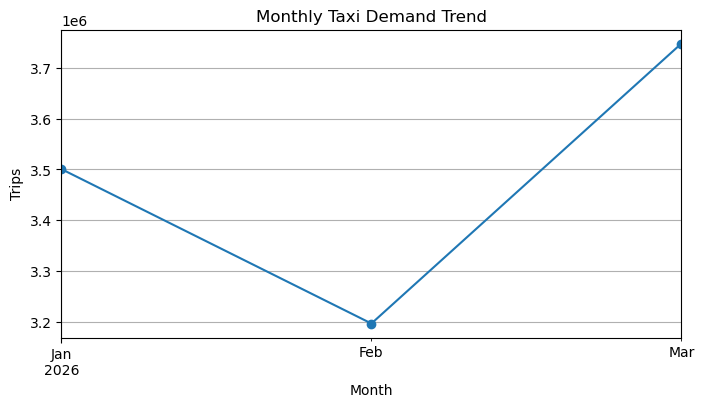

In [43]:
plt.figure(figsize=(8,4))

monthly_trips.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Taxi Demand Trend"
)

plt.xlabel("Month")
plt.ylabel("Trips")

plt.grid()

plt.show()

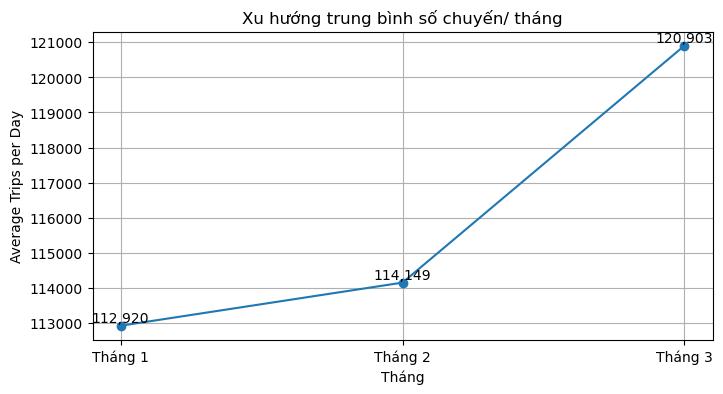

In [44]:
# Xu hướng trung bình số chuyến/ngày theo tháng
month_labels = "Tháng " + monthly_avg["pickup_month"].dt.month.astype(str)

plt.figure(figsize=(8, 4))

plt.plot(
    month_labels,
    monthly_avg["trips_per_day"],
    marker="o"
)

# Ghi giá trị tại mỗi điểm
for x, y in zip(month_labels, monthly_avg["trips_per_day"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom")

plt.title("Xu hướng trung bình số chuyến/ tháng")
plt.xlabel("Tháng")
plt.ylabel("Average Trips per Day")

plt.grid()

plt.show()

#### Nhận xét:

**Tổng số chuyến theo tháng:**
- Tháng 1: ~3,50 triệu chuyến
- Tháng 2: ~3,20 triệu chuyến (thấp nhất)
- Tháng 3: ~3,75 triệu chuyến (cao nhất)

**Trung bình số chuyến/ngày:**
- Tháng 1: ~112.920 chuyến/ngày (thấp nhất)
- Tháng 2: ~114.149 chuyến/ngày
- Tháng 3: ~120.903 chuyến/ngày (cao nhất)

**Kết luận:**
- Tháng 2 có **tổng** số chuyến thấp nhất, nguyên nhân chính là tháng 2 chỉ có 28 ngày so với 31 ngày của tháng 1 và tháng 3. Bên cạnh yếu tố số ngày, tháng 2 còn có **một ngày bất thường 23/02** (chỉ 22.733 chuyến, hụt ~93.000 chuyến so với mức trung bình ~116.000 chuyến/ngày — do bão tuyết). 
- Tháng 3 là tháng có nhu cầu cao nhất(~121K/ngày). Điều này cho thấy nhu cầu di chuyển tăng sau tháng 2, phản ánh điều kiện thời tiết thuận lợi hơn và hoạt động đi lại sôi động hơn khi bước sang đầu mùa xuân.